# hierarchical
> Plot hierarchical clustering for PSSMs

In [ ]:
#| default_exp hierarchical

## Setup

In [ ]:
#| export
from katlas.compare import js_divergence_flat
from kplot.hierarchical import get_1d_distance, get_1d_distance_parallel

/Users/icai/Documents/git/katlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from katlas.data import Data
from katlas.pssm import get_pssm_seq_labels,flatten_pssm
from kplot.hierarchical import get_hcluster

In [ ]:
pssms=Data.get_pspa_scale()

In [ ]:
#| export
def get_1d_js(df): 
    "Compute 1D distance using JS divergence."
    return get_1d_distance(df,js_divergence_flat)

In [ ]:
distance = get_1d_js(pssms.head(20))

100%|██████████| 20/20 [00:00<00:00, 360.94it/s]


In [ ]:
#| export
def get_1d_js_parallel(df, func_flat=js_divergence_flat, **kwargs): 
    "Compute 1D distance matrix using JS divergence."
    return get_1d_distance_parallel(df, func_flat=func_flat, **kwargs)

In [ ]:
distance = get_1d_js_parallel(pssms.head(20))

100%|██████████| 190/190 [00:00<00:00, 5548.41it/s]


## Pipeline of clustering

In [ ]:
# pssms=Data.get_pspa_scale()
# Z = get_Z(pssms,func_flat=js_divergence_flat)
# count_dict = pssms.index.value_counts()
# labels= get_pssm_seq_labels(pssms,count_dict)

# plot_dendrogram(Z,dense=8,labels=labels,thr=0.125)

Or directly use get_hcluster(include calculating Z and plot dendrogram)

100%|██████████| 190/190 [00:00<00:00, 5515.69it/s]


kinase
AAK1       2
ACVR2A     2
ACVR2B     2
AKT1       1
AKT2       1
AKT3       1
ALK2       2
ALK4       2
ALPHAK3    2
AMPKA1     1
AMPKA2     1
ANKRD3     2
ASK1       2
ATM        2
ATR        2
AURA       1
AURB       1
AURC       1
BCKDK      2
BIKE       2
dtype: int32

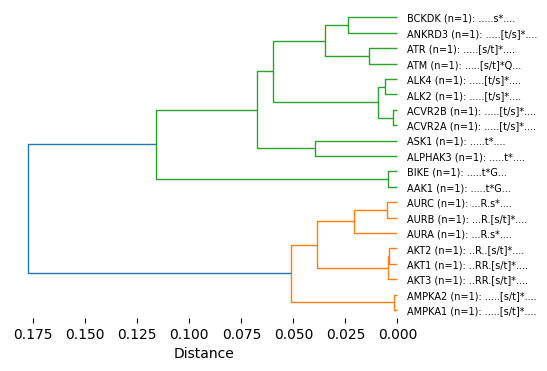

In [ ]:
count_dict = pssms.index.value_counts()
labels= get_pssm_seq_labels(pssms,count_dict)

get_hcluster(pssms.head(20),func_flat=js_divergence_flat,labels=labels[:20],thr=0.125,dense=5)

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()